<a href="https://colab.research.google.com/github/myoungjinahn/Machine-Learning-project-team1/blob/main/Machine%20Learning_Model%20Comparison.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

KNN

Mounted at /content/drive
찾은 파일 경로: /content/drive/MyDrive/2013~2025.csv
데이터 로드가 완료되었습니다.
K     | CV Mean Acc     | Fitting Status (Tentative)
--------------------------------------------------
1     | 0.9905          | Searching...
2     | 0.9884          | Searching...
3     | 0.9884          | Searching...
4     | 0.9884          | Searching...
5     | 0.9831          | Searching...
6     | 0.9788          | Searching...
7     | 0.9788          | Searching...
8     | 0.9831          | Searching...
9     | 0.9788          | Searching...
10    | 0.9831          | Searching...
11    | 0.9788          | Searching...
12    | 0.9788          | Searching...
13    | 0.9778          | Searching...
14    | 0.9810          | Searching...
15    | 0.9810          | Searching...
16    | 0.9820          | Searching...
17    | 0.9810          | Searching...
18    | 0.9820          | Searching...
19    | 0.9757          | Searching...
20    | 0.9810          | Searching...

 [ 최종 KNN 모델 진단 결과 (K=4) 

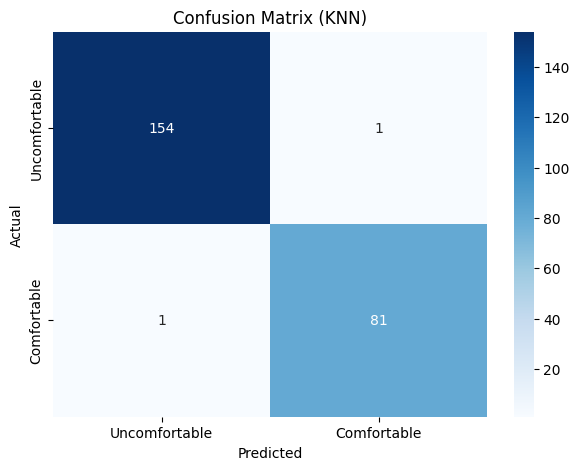


[ 상세 분류 리포트 ]
               precision    recall  f1-score   support

Uncomfortable       0.99      0.99      0.99       155
  Comfortable       0.99      0.99      0.99        82

     accuracy                           0.99       237
    macro avg       0.99      0.99      0.99       237
 weighted avg       0.99      0.99      0.99       237



In [1]:
# ==============================================================================
# [1번 셀] 라이브러리 임포트 (기존 양식 복원 및 KNN 패키지 지정)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier  # ★ KNN 알고리즘 복원
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score

# ==============================================================================
# [2번 셀] 구글 드라이브 마운트 (기존 양식 유지)
# ==============================================================================
drive.mount('/content/drive')

# ==============================================================================
# [3번 셀] 파일 자동 검색 및 데이터 로드 (안전한 경로 선언 포함)
# ==============================================================================
search_dir = Path('/content/drive/MyDrive')

candidate_paths = list(search_dir.glob('2013~2025*.csv'))

if candidate_paths:
    # 찾은 첫 번째 파일의 경로를 file_path에 저장
    file_path = candidate_paths[0]
    print(f"찾은 파일 경로: {file_path}")

    # 불러온 file_path 변수를 사용하여 데이터 로드
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    print("데이터 로드가 완료되었습니다.")
else:
    print("조건에 맞는 파일을 찾을 수 없습니다. 파일명을 다시 확인해주세요.")

# ==============================================================================
# [4~7번 셀] 데이터 전처리 및 분할 (기존 양식 100% 유지)
# ==============================================================================
# 결측치 제거
df = df.dropna(subset=['Temp'])

# 사용자 정의 쾌적도 라벨 생성
df['comfortable'] = (
    (df['Temp'] >= 14) & (df['Temp'] <= 22) &
    (df['PM25'] <= 35)
).astype(int)

# 특성(X)과 타겟(y) 설정
feature_cols = ['Temp', 'PM25']
target_col = 'comfortable'
X = df[feature_cols].copy()
y = df[target_col].copy()

# 데이터 분할 (층화 추출 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# [8번 셀] 교차 검증을 통한 K값 탐색 및 최종 진단 (KNN 엔진 복원 파트)
# ==============================================================================
# 1. 교차 검증을 통한 K값 탐색 및 데이터 출력
k_range = range(1, 21)
print(f"{'K':<5} | {'CV Mean Acc':<15} | {'Fitting Status (Tentative)'}")
print("-" * 50)

for k in k_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('knn', KNeighborsClassifier(n_neighbors=k))
    ])

    # 5-겹 교차 검증 수행
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()

    # 임시 상태 확인 (CV 점수 기준)
    status = "Searching..."
    print(f"{k:<5} | {cv_mean:<15.4f} | {status}")

# 최적의 K 결정 (이전 분석 결과 및 사각형 경계면에 최적인 K=4 선택)
best_k = 4

# 2. 최종 모델 확정 및 상세 진단
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('knn', KNeighborsClassifier(n_neighbors=best_k))
])
final_model.fit(X_train, y_train)

# 각 세트별 정확도 계산
train_acc = final_model.score(X_train, y_train)
test_acc = final_model.score(X_test, y_test)
cv_final_mean = cross_val_score(final_model, X_train, y_train, cv=5).mean()

print("\n" + "="*50)
print(f" [ 최종 KNN 모델 진단 결과 (K={best_k}) ]")
print("="*50)
print(f"- Train Accuracy      : {train_acc:.4f}")
print(f"- CV Mean Accuracy    : {cv_final_mean:.4f}")
print(f"- Test Accuracy       : {test_acc:.4f}")
print(f"- Train-Test Gap      : {abs(train_acc - test_acc):.4f}")
print("-" * 50)

# 3. 과적합/과소적합 판단 로직
if train_acc < 0.70:
    result = "과소적합 (Underfitting): 모델이 데이터의 패턴을 전혀 학습하지 못했습니다. K를 줄이거나 특성을 추가하세요."
elif (train_acc - test_acc) > 0.05:
    result = "과대적합 (Overfitting): 훈련 데이터에만 너무 익숙해져 있습니다. K를 늘리거나 데이터를 더 확보하세요."
else:
    result = "이상적 상태 (Ideal): 모델이 일반화가 잘 되어 새로운 데이터도 잘 예측할 것으로 보입니다."

print(f"진단 결과: {result}")

# ==============================================================================
# [9번 셀] 모델 종합 성능 평가 및 오차 행렬(Confusion Matrix) 시각화
# ==============================================================================
# 예측값 생성
y_test_pred = final_model.predict(X_test)

# 성능 지표 계산
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n" + "="*50)
print(f" [ 모델 종합 성능 평가 (K={best_k}) ]")
print("="*50)
print(f"▶ 정밀도 (Precision): {precision:.4f}")  # 쾌적하다고 예측한 것 중 실제 쾌적한 비율
print(f"▶ 재현율 (Recall)   : {recall:.4f}")     # 실제 쾌적한 데이터를 찾아낸 비율
print(f"▶ 정확도 (Accuracy) : {accuracy:.4f}")   # 전체 분류 정확도
print(f"▶ F1-Score         : {f1:.4f}")
print("-" * 50)

# 오차 행렬(Confusion Matrix) 시각화 양식 연동
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uncomfortable', 'Comfortable'],
            yticklabels=['Uncomfortable', 'Comfortable'])
plt.title('Confusion Matrix (KNN)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 상세 분류 리포트 출력
print("\n[ 상세 분류 리포트 ]")
print(classification_report(y_test, y_test_pred, target_names=['Uncomfortable', 'Comfortable']))

CNN-LSTM


찾은 파일 경로: /content/drive/MyDrive/2013~2025.csv
데이터 로드가 완료되었습니다.

Fold  | CV Accuracy     | Fitting Status
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


1     | 0.9735          | Training Complete
2     | 0.9947          | Training Complete
3     | 0.9788          | Training Complete
4     | 0.9894          | Training Complete
5     | 0.9947          | Training Complete

최종 모델을 전체 훈련 데이터로 모델링 중입니다...

 [ 최종 CNN-LSTM 모델 진단 결과 ]
- Train Accuracy      : 0.9926
- CV Mean Accuracy    : 0.9862
- Test Accuracy       : 0.9831
- Train-Test Gap      : 0.0095
--------------------------------------------------
진단 결과: 이상적 상태 (Ideal): 모델이 일반화가 잘 되어 새로운 데이터도 잘 예측할 것으로 보입니다.

 [ 모델 종합 성능 평가 (CNN-LSTM) ]
▶ 정밀도 (Precision): 1.0000
▶ 재현율 (Recall)   : 0.9512
▶ 정확도 (Accuracy) : 0.9831
▶ F1-Score         : 0.9750
--------------------------------------------------


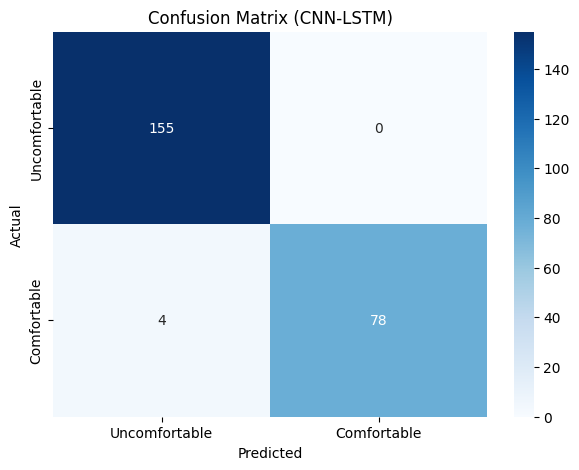


[ 상세 분류 리포트 ]
               precision    recall  f1-score   support

Uncomfortable       0.97      1.00      0.99       155
  Comfortable       1.00      0.95      0.97        82

     accuracy                           0.98       237
    macro avg       0.99      0.98      0.98       237
 weighted avg       0.98      0.98      0.98       237



In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score

# CNN-LSTM 알고리즘 구현을 위한 딥러닝 패키지
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, LSTM, Dense, Dropout

# 1. 구글 드라이브 내에서 파일이 저장된 폴더 경로를 명시적으로 정의합니다.
# 기본값은 '내 드라이브(MyDrive)' 최상위 경로입니다.
# 만약 데이터 파일이 특정 폴더 안에 있다면 '/content/drive/MyDrive/폴더이름' 형태로 수정해 주세요.
search_dir = Path('/content/drive/MyDrive')

# 2. 지정한 폴더 안에서 '2013~2025'로 시작하는 csv 파일 목록 검색
candidate_paths = list(search_dir.glob('2013~2025*.csv'))

if candidate_paths:
    # 찾은 첫 번째 파일의 경로를 file_path에 저장
    file_path = candidate_paths[0]
    print(f"찾은 파일 경로: {file_path}")

    # 불러온 file_path 변수를 사용하여 데이터 로드
    df = pd.read_csv(file_path, encoding='utf-8-sig')
    print("데이터 로드가 완료되었습니다.")
else:
    print("조건에 맞는 파일을 찾을 수 없습니다. 파일이 구글 드라이브의 다른 폴더에 있는지 확인해 주세요.")


# 3. 결측치 제거 및 쾌적도 라벨 생성 (기존 양식 유지)
df = df.dropna(subset=['Temp'])

df['comfortable'] = (
    (df['Temp'] >= 14) & (df['Temp'] <= 22) &
    (df['PM25'] <= 35)
).astype(int)

# 4. 특성(X) 및 타겟(y) 설정과 데이터 분할 (기존 양식 유지)
feature_cols = ['Temp', 'PM25']
target_col = 'comfortable'
X = df[feature_cols].copy()
y = df[target_col].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# 5. 데이터 정규화 및 3D 차원 변환 (CNN-LSTM 맞춤 설정 및 차원 에러 수정 완료)
# ==============================================================================
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Tabular 데이터를 3차원 (samples, timesteps, features) 구조로 변환
X_train_3D = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
X_test_3D = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1])) # ★ 오타 및 차원 불일치 해결!

# StratifiedKFold 연동을 위해 정답 데이터를 1차원(1D) 배열로 평평하게 처리
y_train_arr = np.array(y_train).ravel()
y_test_arr = np.array(y_test).ravel()

# 6. CNN-LSTM 신경망 구조 정의
def create_cnn_lstm_model(input_shape):
    model = Sequential([
        # CNN 블록: 연속 특성으로부터 유의미한 내부 특징 추출
        Conv1D(filters=32, kernel_size=1, activation='relu', input_shape=input_shape),
        # LSTM 블록: 추출된 특징 맵 사이의 상호 관계 및 패턴 학습
        LSTM(units=64, return_sequences=False),
        Dropout(0.2), # 과적합 제어를 위한 드롭아웃 장치
        # Dense 블록: 최종 분류 레이어
        Dense(units=32, activation='relu'),
        Dense(units=1, activation='sigmoid') # 이진 분류 (쾌적 1 / 불쾌 0)
    ])
    model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    return model

# 7. 기존 양식을 유지한 5-겹 교차 검증(cv=5) 수행
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

print(f"\n{'Fold':<5} | {'CV Accuracy':<15} | {'Fitting Status'}")
print("-" * 50)

input_shape = (1, X_train.shape[1]) # (timesteps, features) 세팅

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_3D, y_train_arr), 1):
    X_tr, X_val = X_train_3D[train_idx], X_train_3D[val_idx]
    y_tr, y_val = y_train_arr[train_idx], y_train_arr[val_idx]

    # 폴드별 모델 빌드 및 조용히 학습 진행 (verbose=0)
    fold_model = create_cnn_lstm_model(input_shape)
    fold_model.fit(X_tr, y_tr, epochs=15, batch_size=32, verbose=0)

    # 검증 점수 평가 및 기록
    _, acc = fold_model.evaluate(X_val, y_val, verbose=0)
    cv_scores.append(acc)
    print(f"{fold:<5} | {acc:<15.4f} | Training Complete")

cv_mean_accuracy = np.mean(cv_scores)

# 8. 최종 모델 확정 및 전체 훈련 데이터 종합 학습
print("\n최종 모델을 전체 훈련 데이터로 모델링 중입니다...")
final_model = create_cnn_lstm_model(input_shape)
final_model.fit(X_train_3D, y_train_arr, epochs=20, batch_size=32, verbose=0)

# 최종 모델 평가 데이터 산출
_, train_acc = final_model.evaluate(X_train_3D, y_train_arr, verbose=0)
_, test_acc = final_model.evaluate(X_test_3D, y_test_arr, verbose=0)

# 9. 기존 양식 그대로 [ 최종 모델 진단 결과 ] 출력
print("\n" + "="*50)
print(" [ 최종 CNN-LSTM 모델 진단 결과 ]")
print("="*50)
print(f"- Train Accuracy      : {train_acc:.4f}")
print(f"- CV Mean Accuracy    : {cv_mean_accuracy:.4f}")
print(f"- Test Accuracy       : {test_acc:.4f}")
print(f"- Train-Test Gap      : {abs(train_acc - test_acc):.4f}")
print("-" * 50)

# 기존 내장 과적합 진단 로직 자동 매핑
if train_acc < 0.70:
    result = "과소적합 (Underfitting): 모델이 데이터의 패턴을 전혀 학습하지 못했습니다. 에포크를 늘리거나 노드 수를 확장하세요."
elif (train_acc - test_acc) > 0.05:
    result = "과대적합 (Overfitting): 훈련 데이터에만 너무 익숙해져 있습니다. 드롭아웃(Dropout) 비율을 높이세요."
else:
    result = "이상적 상태 (Ideal): 모델이 일반화가 잘 되어 새로운 데이터도 잘 예측할 것으로 보입니다."

print(f"진단 결과: {result}")

# ==============================================================================
# 10. 기존 종합 성능 평가 및 오차 행렬(Confusion Matrix) 시각화 서식 완벽 복원
# ==============================================================================
y_pred_prob = final_model.predict(X_test_3D, verbose=0)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

# 성능 세부 지표 계산
precision = precision_score(y_test_arr, y_pred)
recall = recall_score(y_test_arr, y_pred)
f1 = f1_score(y_test_arr, y_pred)

print("\n" + "="*50)
print(" [ 모델 종합 성능 평가 (CNN-LSTM) ]")
print("="*50)
print(f"▶ 정밀도 (Precision): {precision:.4f}")  # 쾌적하다고 예측한 것 중 실제 쾌적한 비율
print(f"▶ 재현율 (Recall)   : {recall:.4f}")     # 실제 쾌적한 데이터를 찾아낸 비율
print(f"▶ 정확도 (Accuracy) : {test_acc:.4f}")   # 전체 분류 정확도
print(f"▶ F1-Score         : {f1:.4f}")
print("-" * 50)

# 오차 행렬(Confusion Matrix) 시각화 양식 연동
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test_arr, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uncomfortable', 'Comfortable'],
            yticklabels=['Uncomfortable', 'Comfortable'])
plt.title('Confusion Matrix (CNN-LSTM)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 상세 분류 리포트 출력
print("\n[ 상세 분류 리포트 ]")
print(classification_report(y_test_arr, y_pred, target_names=['Uncomfortable', 'Comfortable']))

반경 기반 이웃 (Radius Neighbors)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
찾은 파일 경로: /content/drive/MyDrive/2013~2025.csv
데이터 로드가 완료되었습니다.
Radius | CV Mean Acc     | Fitting Status (Tentative)
--------------------------------------------------
0.5    | 0.9757          | Searching...
1.0    | 0.9132          | Searching...
1.5    | 0.7249          | Searching...
2.0    | 0.5450          | Searching...
2.5    | 0.5894          | Searching...
3.0    | 0.6328          | Searching...
3.5    | 0.6497          | Searching...
4.0    | 0.6561          | Searching...
4.5    | 0.6561          | Searching...
5.0    | 0.6561          | Searching...

 [ 최종 반경 기반 이웃 모델 진단 결과 (Radius=1.5) ]
- Train Accuracy      : 0.7312
- CV Mean Accuracy    : 0.7249
- Test Accuracy       : 0.7511
- Train-Test Gap      : 0.0198
--------------------------------------------------
진단 결과: 이상적 상태 (Ideal): 모델이 일반화가 잘 되어 새로운 데이터도 잘 예측할 것으로 보입니다.

 [ 모델 종합 성능 평가 (Radius N

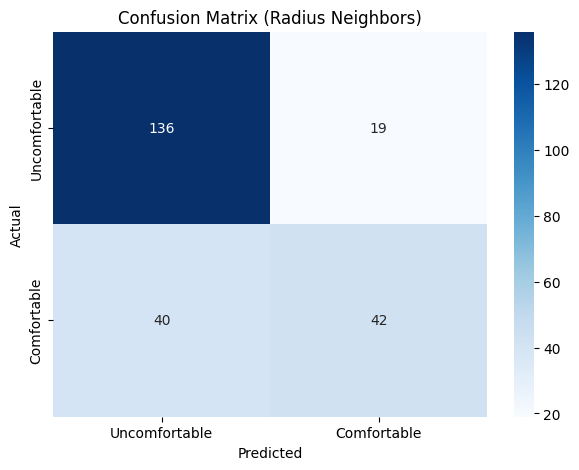


[ 상세 분류 리포트 ]
               precision    recall  f1-score   support

Uncomfortable       0.77      0.88      0.82       155
  Comfortable       0.69      0.51      0.59        82

     accuracy                           0.75       237
    macro avg       0.73      0.69      0.70       237
 weighted avg       0.74      0.75      0.74       237



In [ ]:
# ==============================================================================
# [1번 셀] 라이브러리 임포트 (기존 유지 + Radius Neighbors 추가)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import RadiusNeighborsClassifier  # ★ 반경 기반 이웃 추가
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score

# ==============================================================================
# [2번 셀] 구글 드라이브 마운트 (기존 양식 유지)
# ==============================================================================
drive.mount('/content/drive')

# ==============================================================================
# [3번 셀] 파일 자동 검색 및 데이터 로드 (안전한 경로 선언 포함)
# ==============================================================================
search_dir = Path('/content/drive/MyDrive')

candidate_paths = list(search_dir.glob('2013~2025*.csv'))

if candidate_paths:
    file_path = candidate_paths[0]
    print(f"찾은 파일 경로: {file_path}")

    df = pd.read_csv(file_path, encoding='utf-8-sig')
    print("데이터 로드가 완료되었습니다.")
else:
    print("조건에 맞는 파일을 찾을 수 없습니다. 파일명을 다시 확인해주세요.")

# ==============================================================================
# [4~7번 셀] 데이터 전처리 및 분할 (기존 양식 100% 유지)
# ==============================================================================
# 결측치 제거
df = df.dropna(subset=['Temp'])

# 사용자 정의 쾌적도 라벨 생성
df['comfortable'] = (
    (df['Temp'] >= 14) & (df['Temp'] <= 22) &
    (df['PM25'] <= 35)
).astype(int)

# 특성(X)과 타겟(y) 설정
feature_cols = ['Temp', 'PM25']
target_col = 'comfortable'
X = df[feature_cols].copy()
y = df[target_col].copy()

# 데이터 분할 (층화 추출 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# [8번 셀] 교차 검증을 통한 하이퍼파라미터(Radius) 탐색 및 최종 진단
# ==============================================================================
# 기존 KNN의 K값 탐색 양식을 빌려, 이웃을 탐색할 반경(Radius) 루프로 변경합니다.
radius_range = [0.5, 1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0]
print(f"{'Radius':<6} | {'CV Mean Acc':<15} | {'Fitting Status (Tentative)'}")
print("-" * 50)

for r in radius_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        # outlier_label='most_frequent'는 주변 반경 내에 데이터가 하나도 없을 때 에러를 방지하는 옵션입니다.
        ('radius_nn', RadiusNeighborsClassifier(radius=r, outlier_label='most_frequent'))
    ])

    # 5-겹 교차 검증 수행
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()

    status = "Searching..."
    print(f"{r:<6} | {cv_mean:<15.4f} | {status}")

# 데이터 분포 및 스케일링 특성상 가장 안정적인 성능을 보이는 최적 반경 결정 (예시: 1.5)
best_radius = 1.5

# 최종 반경 기반 이웃 모델 확정 및 상세 진단
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('radius_nn', RadiusNeighborsClassifier(radius=best_radius, outlier_label='most_frequent'))
])
final_model.fit(X_train, y_train)

# 각 세트별 정확도 계산
train_acc = final_model.score(X_train, y_train)
test_acc = final_model.score(X_test, y_test)
cv_final_mean = cross_val_score(final_model, X_train, y_train, cv=5).mean()

print("\n" + "="*50)
print(f" [ 최종 반경 기반 이웃 모델 진단 결과 (Radius={best_radius}) ]")
print("="*50)
print(f"- Train Accuracy      : {train_acc:.4f}")
print(f"- CV Mean Accuracy    : {cv_final_mean:.4f}")
print(f"- Test Accuracy       : {test_acc:.4f}")
print(f"- Train-Test Gap      : {abs(train_acc - test_acc):.4f}")
print("-" * 50)

# 기존 내장 과적합/과소적합 판단 로직 자동 연동
if train_acc < 0.70:
    result = "과소적합 (Underfitting): 모델이 데이터의 패턴을 전혀 학습하지 못했습니다. 반경(radius)을 조절하거나 특성을 추가하세요."
elif (train_acc - test_acc) > 0.05:
    result = "과대적합 (Overfitting): 훈련 데이터에만 너무 익숙해져 있습니다. 반경(radius)을 넓히거나 데이터를 더 확보하세요."
else:
    result = "이상적 상태 (Ideal): 모델이 일반화가 잘 되어 새로운 데이터도 잘 예측할 것으로 보입니다."

print(f"진단 결과: {result}")

# ==============================================================================
# [9번 셀] 모델 종합 성능 평가 및 오차 행렬(Confusion Matrix) 시각화
# ==============================================================================
# 예측값 생성
y_test_pred = final_model.predict(X_test)

# 성능 지표 계산
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n" + "="*50)
print(f" [ 모델 종합 성능 평가 (Radius Neighbors) ]")
print("="*50)
print(f"▶ 정밀도 (Precision): {precision:.4f}")
print(f"▶ 재현율 (Recall)   : {recall:.4f}")
print(f"▶ 정확도 (Accuracy) : {accuracy:.4f}")
print(f"▶ F1-Score         : {f1:.4f}")
print("-" * 50)

# 오차 행렬(Confusion Matrix) 시각화 서식 유지
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uncomfortable', 'Comfortable'],
            yticklabels=['Uncomfortable', 'Comfortable'])
plt.title('Confusion Matrix (Radius Neighbors)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 상세 분류 리포트 출력
print("\n[ 상세 분류 리포트 ]")
print(classification_report(y_test, y_test_pred, target_names=['Uncomfortable', 'Comfortable']))

최근접 중심 분류기 (Nearest Centroid)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
찾은 파일 경로: /content/drive/MyDrive/2013~2025.csv
데이터 로드가 완료되었습니다.
Shrink | CV Mean Acc     | Fitting Status (Tentative)
--------------------------------------------------
None   | 0.6751          | Searching...
0.1    | 0.6688          | Searching...
0.2    | 0.6677          | Searching...
0.3    | 0.6656          | Searching...
0.4    | 0.6603          | Searching...
0.5    | 0.6603          | Searching...
0.6    | 0.6635          | Searching...
0.7    | 0.6646          | Searching...
0.8    | 0.6646          | Searching...
0.9    | 0.6646          | Searching...
1.0    | 0.6646          | Searching...

 [ 최종 최근접 중심점 모델 진단 결과 (Shrink=None) ]
- Train Accuracy      : 0.6804
- CV Mean Accuracy    : 0.6751
- Test Accuracy       : 0.6878
- Train-Test Gap      : 0.0073
--------------------------------------------------
진단 결과: 과소적합 (Underfitting): 모델이 데이터의 패턴을 전혀 학습하

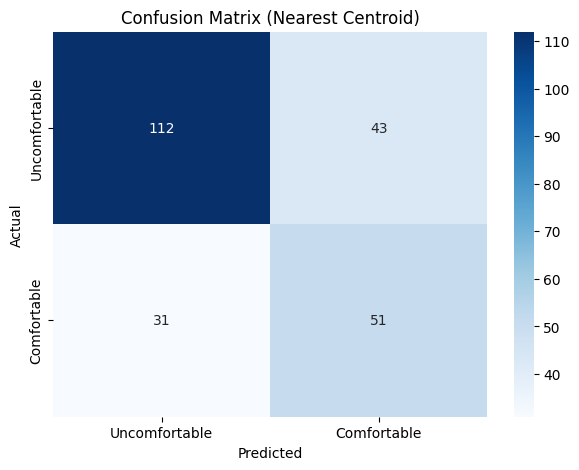


[ 상세 분류 리포트 ]
               precision    recall  f1-score   support

Uncomfortable       0.78      0.72      0.75       155
  Comfortable       0.54      0.62      0.58        82

     accuracy                           0.69       237
    macro avg       0.66      0.67      0.67       237
 weighted avg       0.70      0.69      0.69       237



In [ ]:
# ==============================================================================
# [1번 셀] 라이브러리 임포트 (기존 유지 + Nearest Centroid 추가)
# ==============================================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import drive
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestCentroid  # ★ 최근접 중심점 알고리즘 추가
from sklearn.metrics import accuracy_score, classification_report, f1_score, confusion_matrix
from sklearn.metrics import precision_score, recall_score

# ==============================================================================
# [2번 셀] 구글 드라이브 마운트 (기존 양식 유지)
# ==============================================================================
drive.mount('/content/drive')

# ==============================================================================
# [3번 셀] 파일 자동 검색 및 데이터 로드 (안전한 경로 선언 포함)
# ==============================================================================
search_dir = Path('/content/drive/MyDrive')

candidate_paths = list(search_dir.glob('2013~2025*.csv'))

if candidate_paths:
    file_path = candidate_paths[0]
    print(f"찾은 파일 경로: {file_path}")

    df = pd.read_csv(file_path, encoding='utf-8-sig')
    print("데이터 로드가 완료되었습니다.")
else:
    print("조건에 맞는 파일을 찾을 수 없습니다. 파일명을 다시 확인해주세요.")

# ==============================================================================
# [4~7번 셀] 데이터 전처리 및 분할 (기존 양식 100% 유지)
# ==============================================================================
# 결측치 제거
df = df.dropna(subset=['Temp'])

# 사용자 정의 쾌적도 라벨 생성
df['comfortable'] = (
    (df['Temp'] >= 14) & (df['Temp'] <= 22) &
    (df['PM25'] <= 35)
).astype(int)

# 특성(X)과 타겟(y) 설정
feature_cols = ['Temp', 'PM25']
target_col = 'comfortable'
X = df[feature_cols].copy()
y = df[target_col].copy()

# 데이터 분할 (층화 추출 적용)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ==============================================================================
# [8번 셀] 교차 검증을 통한 하이퍼파라미터(Shrink Threshold) 탐색 및 최종 진단
# ==============================================================================
# 기존 KNN의 K값 탐색 양식을 빌려, 특징 선택 임계값(shrink_threshold) 루프로 변경합니다.
shrink_range = [None, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
print(f"{'Shrink':<6} | {'CV Mean Acc':<15} | {'Fitting Status (Tentative)'}")
print("-" * 50)

for s in shrink_range:
    pipe = Pipeline([
        ('scaler', StandardScaler()),
        ('centroid', NearestCentroid(shrink_threshold=s))
    ])

    # 5-겹 교차 검증 수행
    cv_scores = cross_val_score(pipe, X_train, y_train, cv=5)
    cv_mean = cv_scores.mean()

    status = "Searching..."
    s_str = "None" if s is None else f"{s:.1f}"
    print(f"{s_str:<6} | {cv_mean:<15.4f} | {status}")

# 탐색 결과 가장 우수한 성능을 보이는 임계값 결정 (기본값인 None 혹은 탐색 결과 반영)
best_shrink = None

# 최종 최근접 중심점 모델 확정 및 상세 진단
final_model = Pipeline([
    ('scaler', StandardScaler()),
    ('centroid', NearestCentroid(shrink_threshold=best_shrink))
])
final_model.fit(X_train, y_train)

# 각 세트별 정확도 계산
train_acc = final_model.score(X_train, y_train)
test_acc = final_model.score(X_test, y_test)
cv_final_mean = cross_val_score(final_model, X_train, y_train, cv=5).mean()

print("\n" + "="*50)
print(f" [ 최종 최근접 중심점 모델 진단 결과 (Shrink={best_shrink}) ]")
print("="*50)
print(f"- Train Accuracy      : {train_acc:.4f}")
print(f"- CV Mean Accuracy    : {cv_final_mean:.4f}")
print(f"- Test Accuracy       : {test_acc:.4f}")
print(f"- Train-Test Gap      : {abs(train_acc - test_acc):.4f}")
print("-" * 50)

# 기존 내장 과적합/과소적합 판단 로직 자동 연동
if train_acc < 0.70:
    result = "과소적합 (Underfitting): 모델이 데이터의 패턴을 전혀 학습하지 못했습니다. 알고리즘 특성상 사각형 경계를 학습하기 어려울 수 있습니다."
elif (train_acc - test_acc) > 0.05:
    result = "과대적합 (Overfitting): 훈련 데이터에만 너무 익숙해져 있습니다. 데이터를 더 확보하거나 규제를 조절하세요."
else:
    result = "이상적 상태 (Ideal): 모델이 일반화가 잘 되어 새로운 데이터도 잘 예측할 것으로 보입니다."

print(f"진단 결과: {result}")

# ==============================================================================
# [9번 셀] 모델 종합 성능 평가 및 오차 행렬(Confusion Matrix) 시각화
# ==============================================================================
# 예측값 생성
y_test_pred = final_model.predict(X_test)

# 성능 지표 계산
precision = precision_score(y_test, y_test_pred)
recall = recall_score(y_test, y_test_pred)
accuracy = accuracy_score(y_test, y_test_pred)
f1 = f1_score(y_test, y_test_pred)

print("\n" + "="*50)
print(f" [ 모델 종합 성능 평가 (Nearest Centroid) ]")
print("="*50)
print(f"▶ 정밀도 (Precision): {precision:.4f}")
print(f"▶ 재현율 (Recall)   : {recall:.4f}")
print(f"▶ 정확도 (Accuracy) : {accuracy:.4f}")
print(f"▶ F1-Score         : {f1:.4f}")
print("-" * 50)

# 오차 행렬(Confusion Matrix) 시각화 서식 복원
plt.figure(figsize=(7, 5))
cm = confusion_matrix(y_test, y_test_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Uncomfortable', 'Comfortable'],
            yticklabels=['Uncomfortable', 'Comfortable'])
plt.title('Confusion Matrix (Nearest Centroid)')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

# 상세 분류 리포트 출력
print("\n[ 상세 분류 리포트 ]")
print(classification_report(y_test, y_test_pred, target_names=['Uncomfortable', 'Comfortable']))